# Plot GNN training metrics across all microscopes

In [10]:
from sklearn.neural_network import MLPClassifier
import pickle
import os
import pandas as pd
import anndata
import scanpy as sc
from tqdm import tqdm
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
import torch
import math
from sklearn.model_selection import train_test_split, KFold
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_1samp
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_1samp
from sklearn import svm
from sklearn.linear_model import LogisticRegression

from statannot import add_stat_annotation
import torch
import pandas as pd
import torch.nn.functional as F
import torch.nn as nn
from torch_geometric.nn import global_mean_pool, global_max_pool, SAGPooling, TopKPooling, global_add_pool
from torch_geometric.nn import DenseGCNConv
import torch_geometric.transforms as T
from torch_geometric.nn import GATConv, GCNConv
from torch_geometric.data import Dataset, DataLoader, DenseDataLoader
import os
import pickle
import random
import math
import numpy as np
from torchmetrics.classification import MulticlassAUROC, MulticlassAccuracy
from tqdm import tqdm
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import sys
import umap
import matplotlib.pyplot as plt
import seaborn as sns
import time
from datetime import datetime
from joblib import Parallel, delayed

import os.path as osp
from torch_geometric.explain import Explainer, GNNExplainer
# from dgl.nn import AvgPooling, GNNExplainer
from pathlib import Path

sns.set_style("whitegrid")
sns.set(font_scale=2)

# user directories and inputs

In [ ]:
# excel file of model paths to compare
dfMicroscopes = pd.read_excel(Path(r"..\data\01 Human lung tissues compared\01 Human lung microscopes compared.xlsx"))
dfMicroscopes.loc[dfMicroscopes['GraphModelPath'].drop_duplicates().index, :] # widefield, localized, and confocal
print(dfMicroscopes)

# folder to save plot screenshots
screenshotSavePath = Path(r"..\figures")
assert screenshotSavePath.exists()

               SampleID            Treatment Microscope  \
0  577-1195_3 slide 003  Osimertinib 1.8 cm   Widefield   
1  577-1195_3 slide 003  Osimertinib 1.8 cm   Localized   
2  577-1195_3 slide 003  Osimertinib 1.8 cm    Confocal   
3  x747-131_6 slide 003   Osimertinib 8.3 cm  Widefield   
4  x747-131_6 slide 003   Osimertinib 8.3 cm  Localized   
5  x747-131_6 slide 003   Osimertinib 8.3 cm   Confocal   
6  577-1215_5 slide 003    Gefitinib 2.6 cm   Widefield   
7  577-1215_5 slide 003    Gefitinib 2.6 cm   Localized   
8  577-1215_5 slide 003    Gefitinib 2.6 cm    Confocal   

                                             PklPath  \
0  Y:\coskun-lab\Nicky\47 PLA super resolution\Da...   
1  Y:\coskun-lab\Nicky\47 PLA super resolution\Da...   
2  Y:\coskun-lab\Nicky\47 PLA super resolution\Da...   
3  Y:\coskun-lab\Nicky\47 PLA super resolution\Da...   
4  Y:\coskun-lab\Nicky\47 PLA super resolution\Da...   
5  Y:\coskun-lab\Nicky\47 PLA super resolution\Da...   
6  Y:\coskun-lab\

# Read metrics for all trained GNN models. Select best based on validation ACC, AUC, accuracy, etc.

In [12]:
# read metrics in parallel
def readMetrics(path, microscope):
    
    dfMetrics = pd.read_csv(path)

    # add model structure info
    structure = path.parts[-6:]

    # select best performing validation score
    valScores = [c for c in dfMetrics.columns if 'val' in c]
    # dfMetrics.dropna(subset = valScores, inplace = True)
    score = dfMetrics[valScores].max() # may need to change this
    score['Structure'] = structure
    # add microscope info
    score['Microscope'] = microscope

    assert not score.isna().any()

    return score

dfAll = []
for row1 in dfMicroscopes.itertuples(): # each microscope type

    # search for all metrics files
    metricFiles = [f for f in Path(row1.GraphModelPath).rglob('*.csv') if 'metrics' in f.stem]

    # read metrics in parallel
    results = Parallel(n_jobs = 10, prefer = 'threads', verbose = 5)\
        (delayed(readMetrics)(path = f, microscope = row1.Microscope) for f in metricFiles)
    dfAll.extend(results)

# concatenate results
dfAll = pd.concat(dfAll, axis=1).T
dfAll

[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  52 tasks      | elapsed:    0.1s
[Parallel(n_jobs=10)]: Done 142 tasks      | elapsed:    0.4s
[Parallel(n_jobs=10)]: Done 268 tasks      | elapsed:    0.7s
[Parallel(n_jobs=10)]: Done 430 tasks      | elapsed:    1.2s
[Parallel(n_jobs=10)]: Done 628 tasks      | elapsed:    1.8s
[Parallel(n_jobs=10)]: Done 862 tasks      | elapsed:    2.4s
[Parallel(n_jobs=10)]: Done 1132 tasks      | elapsed:    3.2s
[Parallel(n_jobs=10)]: Done 1438 tasks      | elapsed:    4.1s
[Parallel(n_jobs=10)]: Done 1780 tasks      | elapsed:    5.0s
[Parallel(n_jobs=10)]: Done 1800 out of 1800 | elapsed:    5.1s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  52 tasks      | elapsed:    0.1s
[Parallel(n_jobs=10)]: Done 142 tasks      | elapsed:    0.4s
[Parallel(n_jobs=10)]: Done 268 tasks      | elapsed:    0.8s
[Parallel(n_jobs

,val_acc,val_auc,val_f1,val_loss_epoch,val_loss_step,Structure,Microscope
0,0.732277,0.733661,0.598415,0.941662,0.994389,"(GAT2_2_16_onehot_0, attention, GraphLevelGAT2...",Widefield
1,0.732277,0.732339,0.598415,0.94325,1.031414,"(GAT2_2_16_onehot_0, attention2, GraphLevelGAT...",Widefield
2,0.732277,0.747287,0.598415,0.965974,1.05258,"(GAT2_2_16_onehot_0, max, GraphLevelGAT2, ligh...",Widefield
3,0.732277,0.729233,0.598415,0.942867,1.007583,"(GAT2_2_16_onehot_0, mean, GraphLevelGAT2, lig...",Widefield
4,0.732717,0.754616,0.599739,0.982379,0.995921,"(GAT2_2_16_onehot_0, sum, GraphLevelGAT2, ligh...",Widefield
...,...,...,...,...,...,...,...
16195,0.636364,0.585785,0.489796,2.074604,2.074604,"(GraphConv_4_64_onehot_9, attention, GraphLeve...",Confocal
16196,0.587879,0.608264,0.510067,1.882737,1.882737,"(GraphConv_4_64_onehot_9, attention2, GraphLev...",Confocal
16197,0.569697,0.57124,0.425532,1.976768,1.976768,"(GraphConv_4_64_onehot_9, max, GraphLevelGraph...",Confocal
16198,0.618182,0.613884,0.487805,1.87328,1.87328,"(GraphConv_4_64_onehot_9, mean, GraphLevelGrap...",Confocal


In [13]:
# rename columns for consistency
dfAll.rename(columns = {'val_acc': 'Accuracy', 
                        'val_f1': 'F1', 
                        'val_auc': 'AUC'}, inplace = True)
# relabel microscopes for consistency
dfAll['Microscope'].replace({'Widefield': 'W', 
                             'Localized': 'SRW', 
                             'Confocal': 'Airyscan'}, 
                             inplace = True)

# Plot comapre microscope GNN model performances

In [14]:
def saveFigLabelTime(fig): # save figure with current time as label
    now = datetime.now()
    now = now.strftime('%d%b%Y_%H%M%S')
    fileOut = now + '.png'
    fileOut = os.path.join(screenshotSavePath, fileOut)
    plt.gcf()
    plt.savefig(fileOut, dpi = 'figure', bbox_inches = 'tight', pad_inches = 0)
    
    time.sleep(1) # wait to prevent overwrite

    return None

In [15]:
#  reformat metrics
metrics = ['Accuracy', 'F1', 'AUC']
dfSub = dfAll.melt(id_vars = ['Structure', 'Microscope'], value_vars = metrics, value_name='Score', var_name='Metric')
dfSub['Score'] = dfSub['Score'].astype(float)

p-value annotation legend:
ns: 5.00e-02 < p <= 1.00e+00
*: 1.00e-02 < p <= 5.00e-02
**: 1.00e-03 < p <= 1.00e-02
***: 1.00e-04 < p <= 1.00e-03
****: p <= 1.00e-04

AUC_W v.s. AUC_SRW: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=0.000e+00 U_stat=0.000e+00
F1_SRW v.s. F1_Airyscan: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=0.000e+00 U_stat=2.916e+07
AUC_SRW v.s. AUC_Airyscan: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=0.000e+00 U_stat=2.916e+07
Accuracy_W v.s. Accuracy_SRW: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=0.000e+00 U_stat=0.000e+00
F1_W v.s. F1_SRW: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=0.000e+00 U_stat=0.000e+00
Accuracy_SRW v.s. Accuracy_Airyscan: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P_val=0.000e+00 U_stat=2.916e+07
AUC_W v.s. AUC_Airyscan: Mann-Whitney-Wilcoxon test two-sided with Bonferroni correction, P

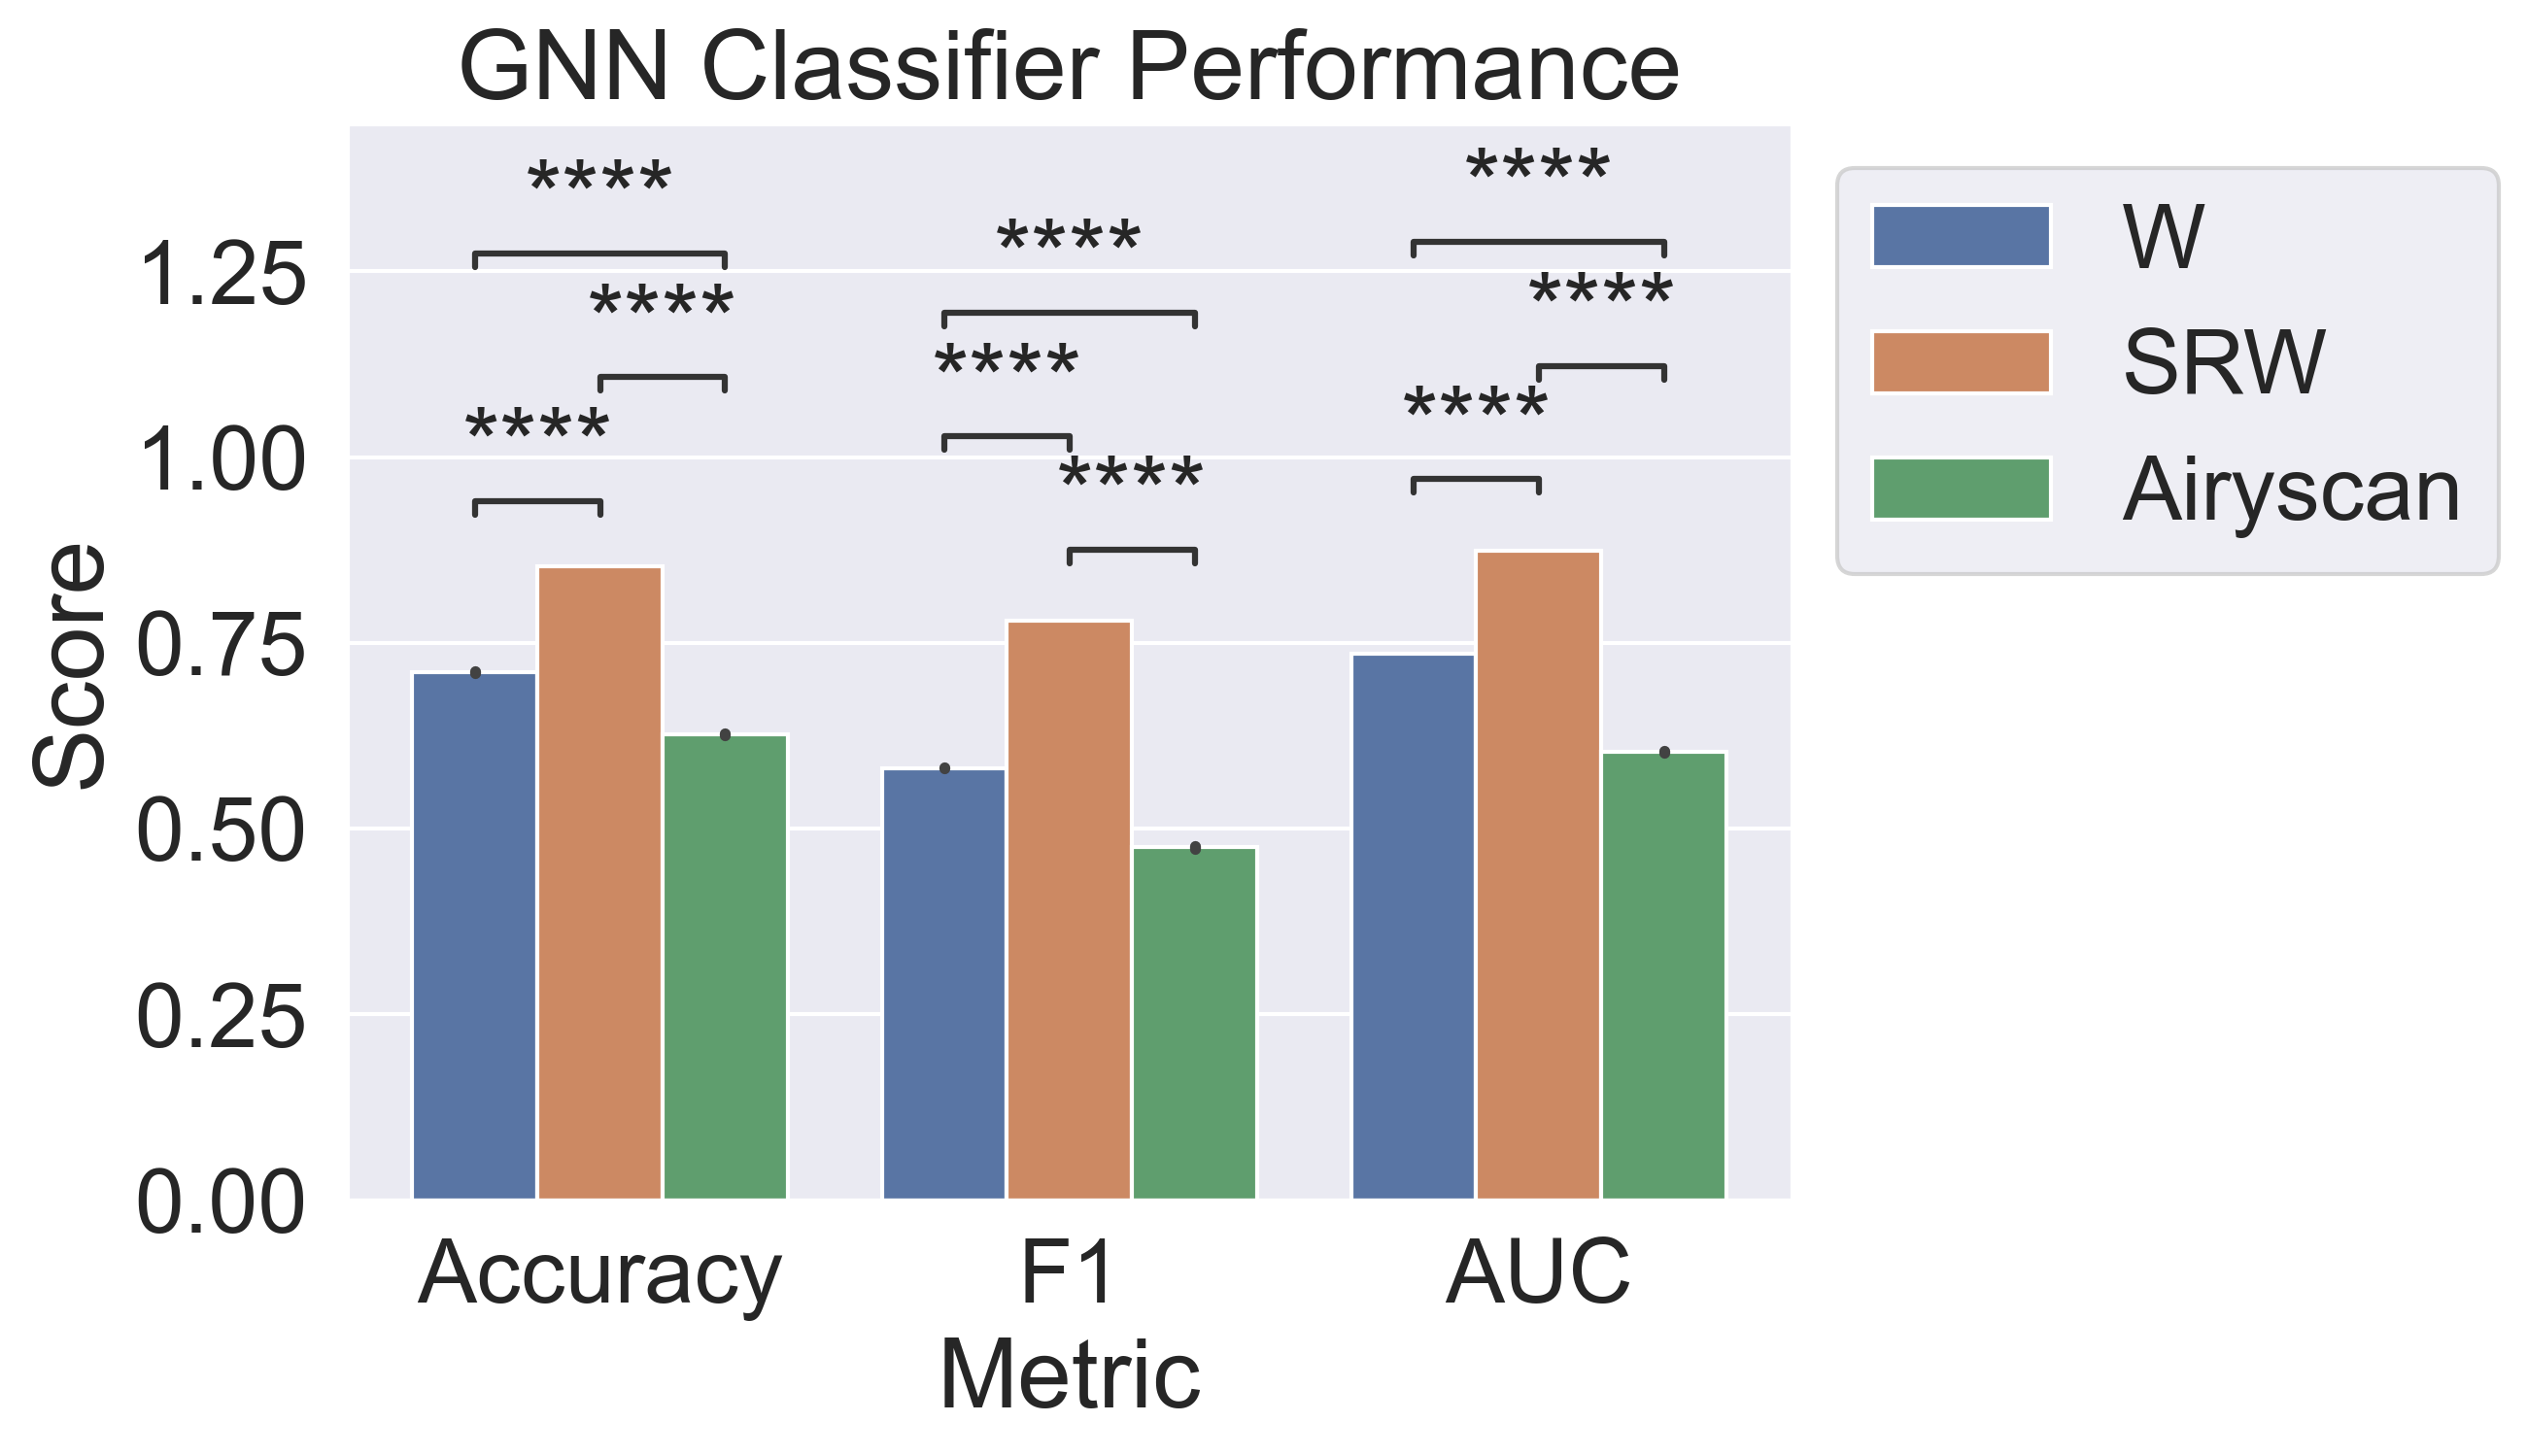

In [16]:
x = 'Metric'
y = 'Score'
hue = 'Microscope'

fig, ax = plt.subplots(dpi = 300)
sns.barplot(data = dfSub, x = x, y = y, hue = hue, ax = ax)
ax.set_title('GNN Classifier Performance')
ax.legend(bbox_to_anchor=(1, 1), loc='upper left')

# add statistical annotation
# all possible pairs of metrics and microscopes
scopes = dfSub[hue].unique()
boxPairs = [((m, scopes[0]), (m, scopes[1])) for m in metrics] + [((m, scopes[0]), (m, scopes[-1])) for m in metrics] + \
    [((m, scopes[1]), (m, scopes[-1])) for m in metrics]
add_stat_annotation(data = dfSub, ax = ax, x = x, y = y, hue = hue, box_pairs = boxPairs, 
                        test = 'Mann-Whitney', text_format = 'star', loc = 'inside', verbose = 2, 
                        comparisons_correction='bonferroni')

# g = sns.barplot(
#     data=stats,
#     x="Metrics", y="Values", hue="Method",
#     errorbar="sd", palette="dark", alpha=.6
# )
# g.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
# g.despine(left=True)
# g.set_axis_labels("", "")
# g.legend.set_title("Performance Comparison")

# add statistical annotation

# # compare GNN against others
# boxPairs = []
# for ii, method in enumerate(stats['Method'].unique()):

#     for jj, metric in enumerate(stats['Metrics'].unique()):

#         if 'GNN' in method: # no need to compare against self
#             continue

#         boxPairs.append([(metric, 'GNN'), 
#                          (metric, method)])

# add_stat_annotation(data = stats, ax = ax, x = x, y = y, hue = hue, box_pairs = boxPairs, 
#                         test = 'Mann-Whitney', text_format = 'star', loc = 'inside', verbose = 2, 
#                         comparisons_correction = 'bonferroni')

# ax.set_ylabel('Performance (AU)')
# ax.set_title('Performance Comparison')

# save figure
saveFigLabelTime(fig)